In [2]:
using Plots, Statistics, Printf, Turing, Optim, HCubature, StatsBase, StatsPlots, CairoMakie, PairPlots

In [14]:
##############################################
# exam scores                                #
##############################################

exam01 = [
    18.3, 52.5, 83.8, 73.0, 74.8, 54.3, 96.3, 98.8, 91.5, 86.3, 100.0, 69.3, 7.5, 68.8,
    61.5, 75.5, 92.5, 82.5, 36.8, 72.5, 29.5, 88.0, 94.3, 84.5, 45.8
]

exams  = (a = exam01, b = exam01);

In [6]:
function plot_workup(data, plt, m, c1, c2, ls)
      
    ###############################################
    # Statistics workup                           #
    ###############################################
    idx     = collect(1:1:length(data))
    s       = std(data)#std(data[end + 1 - lwindow:end])
    xb      = mean(data)#mean(data[end + 1 - lwindow:end])
    
    ##################################################
    # Graphs trends                                  #
    ##################################################
    
    plt = Plots.scatter!(plt, idx, data, marker = m, color = c1, strokecolor = :black, legend = nothing)
    return plt
end

plot_workup (generic function with 1 method)

[69.544, 655.178, 25.596]

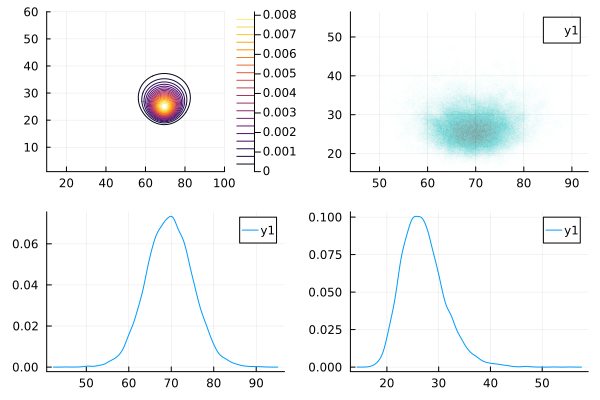

In [19]:
########################################################################################################################### 
# Bayesian Inference on mean and variance of kcal intake -- use continuous functions and hcubature instead of grid  #
###########################################################################################################################

function bayes(data, plt1, plt2, plt3, plt4, plt)
    scores           = Float64.(data[data .> 0])
    println(round.([mean(scores), var(scores), std(scores)], digits = 3))
    
    μset             = collect(range(10, stop = 100, length = 2000))
    σset             = collect(range(1, stop = 60, length = 2000))
    lpr_μ(p1)        = logpdf(Uniform(1, 100), p1)
    lpr_σ(p2)        = logpdf(Uniform(1, 60), p2)
    llk_kcal(p1, p2) = sum(logpdf(Normal(p1, p2), scores))
    lpo_μσ(p1, p2)   = llk_kcal(p1, p2) + lpr_μ(p1) + lpr_σ(p2)
    sol              = optimize(X -> -1*lpo_μσ(X[1], X[2]), [70., 25.])
    maxlpo           = -1*sol.minimum
    lpo_s(p1, p2)    = lpo_μσ(p1, p2) - maxlpo
    Z                = log(hcubature(X -> exp(lpo_s(X[1], X[2])), (1, 1), (100, 60))[1])
    lpo_n(p1, p2)    = lpo_s(p1, p2) - Z
    dataout          = zeros(length(μset), length(σset))
    means            = similar(dataout)
    sigs             = similar(dataout)
    
    ############################################################################
    # Still need grid sampling to examine posterior distributions for μ and σ  #
    ############################################################################
    
    for i = 1:length(μset)
        for j = 1:length(σset)
            dataout[i,j] = lpo_n(μset[i], σset[j])
            means[i, j]  = μset[i]
            sigs[i, j]   = σset[j]
        end
    end
    
    lin_data_out = exp.(dataout)
    
    idx          = sample(1:length(lin_data_out[:]), Weights(lin_data_out[:]), 10000, replace = true)
    sample_means = means[:][idx]
    sample_sigs  = sigs[:][idx]
    
    #############################################################################
    # Generate contour and scatter plots                                        #
    #############################################################################
    
    plt1 = Plots.contour!(plt1, μset, σset, exp.(dataout)', levels = 20)
    plt2 = Plots.scatter!(plt2, sample_means, sample_sigs, alpha = 0.0075, markersize = 4)
    plt3 = Plots.density!(plt3, sample_means)
    plt4 = Plots.density!(plt4, sample_sigs)
    plt  = Plots.plot!(plt1, plt2, plt3, plt4, layout = 4)
    return plt1, plt2, plt3, plt4, plt
end

plt1 = Plots.plot()
plt2 = Plots.plot()
plt3 = Plots.plot()
plt4 = Plots.plot()
plt  = Plots.plot
plt1, plt2, plt3, plt4, plt = bayes(copy(exams[:a]), plt1, plt2, plt3, plt4, plt)
display(plt)